# 8. Защита проекта: 
## А/Б-тестирование по данным НКО "Если быть точным"

### АНАЛИЗ ДАННЫХ:

In [1]:
# Загружаем необходимые библиотеки:
import pandas as pd
import numpy as np

%matplotlib inline
from matplotlib import pyplot as plt

In [2]:
# Получаем необходимые данные:
data = pd.read_csv('PA_15_ab_test_results.csv')

In [3]:
# Смотрим общую информацию о данных:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Day Index            28 non-null     object
 1   Users                28 non-null     int64 
 2   Email Subscriptions  28 non-null     int64 
 3   Group Type           28 non-null     object
dtypes: int64(2), object(2)
memory usage: 1.0+ KB


In [4]:
data.head()

,Day Index,Users,Email Subscriptions,Group Type
0,08/07/20,170,1,control
1,08/07/20,142,3,test
2,09/07/20,100,1,control
3,09/07/20,95,5,test
4,10/07/20,170,2,control


In [5]:
# Удалим ненужную нам колонку с датами
data=data.drop(columns='Day Index')

### ИЗУЧЕНИЕ КЛЮЧЕВОЙ МЕТРИКИ:

In [6]:
# Группируем данные по типу группы, в разрезе пользователей и подписчиков:
data.groupby(['Group Type']).sum()

,Users,Email Subscriptions
Group Type,,
control,2476,18
test,2663,49


In [7]:
# Смотрим на первоначальное значение среднего количества подписок:
print(round(data.groupby('Group Type')['Email Subscriptions'].sum(), 2))

Group Type
control    18
test       49
Name: Email Subscriptions, dtype: int64


In [8]:
# Задаём переменные для пользователей, подписчиков и конверсии из пользователей в подписчиков для тестовой группы:

test_subscribers = data[data['Group Type'] == 'test']['Email Subscriptions'].sum()
print('test subscribers: {}'.format(test_subscribers))

test_users = data[data['Group Type'] == 'test']['Users'].sum()
print('test users: {}'.format(test_users))

test_conversion = test_subscribers / test_users
print('test, subscribers to users conversion: {}'.format(test_conversion))

test subscribers: 49
test users: 2663
test, subscribers to users conversion: 0.01840030041306797


In [9]:
# Задаём переменные для пользователей, подписчиков и конверсии из пользователей в подписчиков для контрольной группы:

control_subscribers = data[data['Group Type'] == 'control']['Email Subscriptions'].sum()
print('control subscribers: {}'.format(control_subscribers))

control_users = data[data['Group Type'] == 'control']['Users'].sum()
print('control users: {}'.format(control_users))

control_conversion = control_subscribers / control_users
print('control, subscribers to users conversion: {}'.format(control_conversion))

control subscribers: 18
control users: 2476
control, subscribers to users conversion: 0.007269789983844911


In [10]:
# Считаем отношение конверсии тестовой к контрольной группе:
test_to_control_conversion = test_conversion / control_conversion
round(test_to_control_conversion, 2)

np.float64(2.53)

##### Здесь, мы видим, что отношение конверсии пользователей в подписчиков в тестовой группе в сравнении с контрольной выросло в 2.53 раза, что может говорить об эффективности тестируемой гипотезы.

In [11]:
# Добавляем столбец с конверсией:
data['conversion'] = data['Email Subscriptions'] / data['Users']

##### для проверки значимости разницы конверсии используется Z-тест

##### Устанавливаем библиотеку с множеством разных статистических функций, в том числе и Z-тест:

In [12]:
from statsmodels.stats.weightstats import ztest

Теперь для теста устанавливаем следующие условия:

Нулевая гипотеза: нет никакой разницы в конверсии между контрольной и тестовой группой.
Альтернативная гипотеза: тестовая группа даёт значимо большую конверсию, чем контрольная.
За α возьмём стандартное значение в 0.05.

##### Применяем Z-test:

In [13]:
print(ztest(data[data['Group Type'] == 'test']['conversion'], data[data['Group Type'] == 'control']['conversion']))

(np.float64(3.053352894266018), np.float64(0.0022629964347533325))


In [14]:
statistic, p_value = ztest(data[data['Group Type'] == 'control']['Email Subscriptions'].values,
                           data[data['Group Type'] == 'test']['Email Subscriptions'].values)

print(f"statistic: {statistic}")
print(f"p_value: {p_value}")

statistic: -4.485259450125895
p_value: 7.282526483342191e-06


In [15]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

In [16]:
count = np.array([18, 49])
nobs = np.array([2476, 2663])
stats, p_value = proportions_ztest(count, nobs)
print(stats, p_value)

-3.5147000645234394 0.00044025091667789374


##### При подсчёте статистической значимости полученной разницы с помощью Z-test, получаем значение p-value равное 0.0004, что меньше уровня значимости 5%.

Считаем межквартильный размах - разницу между крайними значениями у 95% доверительного интервала, с помощью калькулятора >>> https://sample-size.net/confidence-interval-proportion/:

N = 2663 (Sample size)
X = 49 (Number in the sample with the result or finding in question)
CL = 95% (Confidence level)

1. Binomial "exact" calculation
Proportion of positive results = P = x/N = 0.0184
Lower bound = 0.0136
Upper bound = 0.0243

Размах = Upper bound - Lower bound = 0.0243 - 0.0136 = 0.0107

Вычисляем 95% доверительный интервал для полученного значения конверсии тестовой группы. Считаем какой получился размах между крайними значениями, с помощью калькулятора >>> https://sample-size.net/confidence-interval-proportion/

Размах между значениями равен 0.0107 на уровне доверия 95%.
Мы можем считать проверяемую гипотезу успешной.

In [17]:
data_group = data.groupby(['Group Type']).sum().reset_index()
data_group

,Group Type,Users,Email Subscriptions,conversion
0,control,2476,18,0.120338
1,test,2663,49,0.288824


In [18]:
data_group['Users'][0]

np.int64(2476)

### ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ:

Text(0.5, 1.0, 'Количество Подписчиков, в контрольной и тестовой группе')

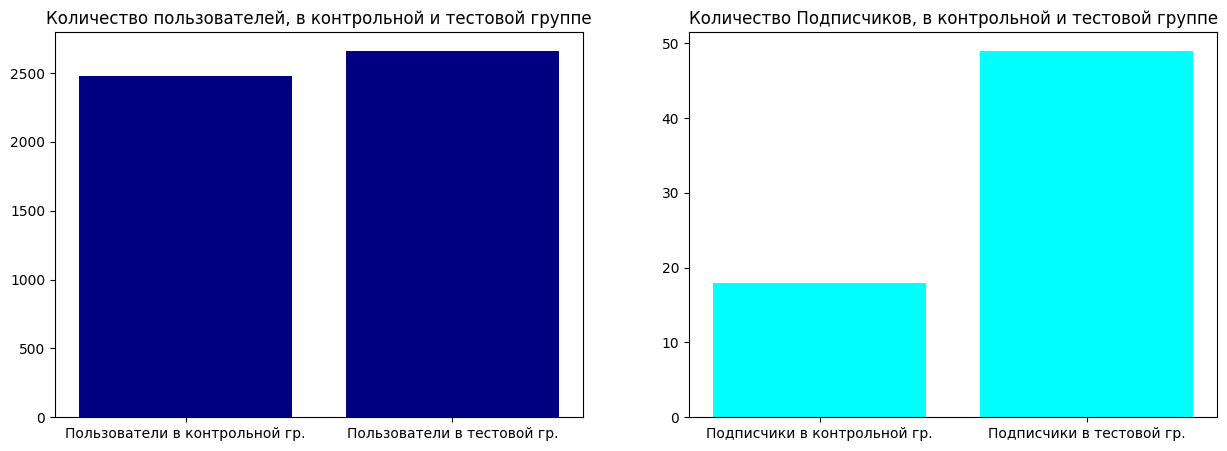

In [19]:
fig, axes = plt.subplots(1, 2, figsize = (15, 5))
axes[0].bar(x = 'Пользователи в контрольной гр.', height = data_group['Users'][0], color = 'navy')
axes[0].bar(x = 'Пользователи в тестовой гр.', height = data_group['Users'][1], color = 'navy')
axes[0].set_title('Количество пользователей, в контрольной и тестовой группе')

axes[1].bar(x = 'Подписчики в контрольной гр.', height = data_group['Email Subscriptions'][0], color = 'aqua')
axes[1].bar(x = 'Подписчики в тестовой гр.', height = data_group['Email Subscriptions'][1], color = 'aqua')
axes[1].set_title('Количество Подписчиков, в контрольной и тестовой группе')

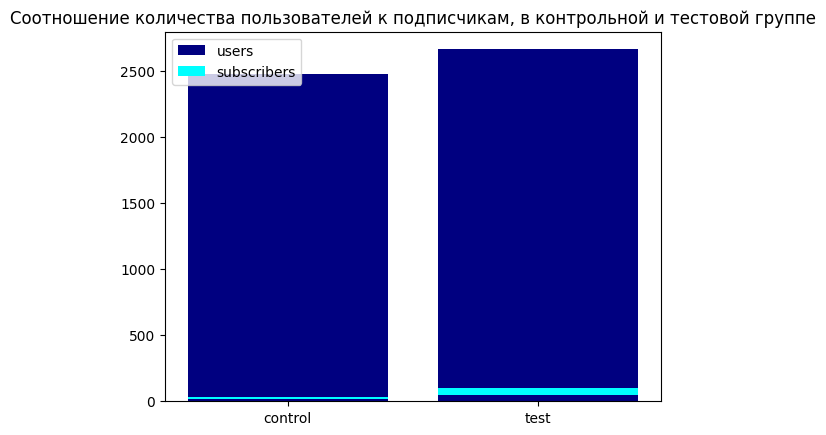

In [20]:
index = np.arange(2)
plt.title('Соотношение количества пользователей к подписчикам, в контрольной и тестовой группе')
plt.bar(index, control_users, color = 'navy')
plt.bar(index, control_subscribers, color = 'aqua', bottom = control_subscribers)
plt.bar(index[1], test_users, color = 'navy')
plt.bar(index[1], test_subscribers, color = 'aqua', bottom = test_subscribers)
plt.xticks(index, ['control', 'test'])
plt.legend(['users', 'subscribers'])
plt.show()

ВЫВОД:
В результате данной визуализации, также видим, что количество подписчиков в тестовой группе: 49 больше, чем в контрольной: 18
Таким образом, конверсия из пользователей в подписчиков в тестовой группе по сравнению с контрольной группой выросла в 2.53 раза, а прирост среднего количества подписок составляет значение в диапазоне от 2.122 до 2.713 раз, с вероятностью 95% - подтверждаем, что эксперимент успешный.

Рекомендации по масштабированию.
На основе успешного результата теста рекомендую немедленно развернуть новый дизайн и формулировки на всю аудиторию. Это будет иметь следующий эффект:
- Увеличение подписчиков: в месяц добавится ~150-200 новых подписчиков (при текущем трафике ~4500 новых пользователей/месяц);
- Снижение затрат: рассылка помогает удерживать пользователей, не требуя разработки новых разделов;
- Долгосрочный эффект: со временем база подписчиков вырастет, и каждая рассылка будет достигать все большей аудитории.

Предлагаю:
1. Отслеживать метрику конверсии в подписку в Google Analytics;
2. Экспериментировать с контентом рассылок — какие темы интересуют подписчиков больше всего;
3. Тестировать частоту рассылок — может быть, рассылка раз в две недели дала бы лучшие результаты;
4. Анализировать удержание подписчиков — открываемость и клики на рассылку.